# Modèle - 9 Variables

## Objectif

Ce notebook implémente un modèle de machine learning utilisant uniquement les **9 variables** identifiées par les analyses statistiques (corrélation et ANOVA). Il compare plusieurs algorithmes (LightGBM, XGBoost, Random Forest, Gradient Boosting), sélectionne le meilleur modèle, et génère les prédictions sur le test set.

**Principales étapes** :
- Chargement des données après feature engineering
- Sélection des 9 variables
- Split train/validation
- Entraînement et comparaison de plusieurs modèles
- Analyse de l'importance des features
- Entraînement final sur toutes les données
- Génération des prédictions sur le test set
- Sauvegarde du modèle et des résultats

## Variables Sélectionnées

### Variables Quantitatives (4) :
1. **OverallQual** : Évaluation de la qualité globale des matériaux et de la finition de la maison (échelle de 1 à 10)
- 1 : Very Poor
- 5 : Average
- 10 : Very Excellent

2. **GrLivArea** : Surface habitable au-dessus du niveau du sol (en pieds carrés)

3. **TotalBsmtSF** : Surface totale du sous-sol (en pieds carrés)

4. **GarageCars** : Capacité du garage en nombre de voitures

### Variables Qualitatives (5) :
1. **Neighborhood** : Emplacement physique dans les limites de la ville d'Ames
- Blmngtn, Blueste, BrDale, BrkSide, ClearCr, CollgCr, Crawfor, Edwards, Gilbert, IDOTRR, MeadowV, Mitchel, Names, NoRidge, NPkVill, NridgHt, NWAmes, OldTown, SWISU, Sawyer, SawyerW, Somerst, StoneBr, Timber, Veenker

2. **ExterQual** : Évaluation de la qualité des matériaux extérieurs
- Ex : Excellent
- Gd : Good
- TA : Average/Typical
- Fa : Fair
- Po : Poor

3. **BsmtQual** : Évaluation de la hauteur du sous-sol
- Ex : Excellent (100+ pouces)
- Gd : Good (90-99 pouces)
- TA : Typical (80-89 pouces)
- Fa : Fair (70-79 pouces)
- Po : Poor (<70 pouces)
- NA : No Basement

4. **KitchenQual** : Qualité de la cuisine
- Ex : Excellent
- Gd : Good
- TA : Typical/Average
- Fa : Fair
- Po : Poor

5. **GarageFinish** : Type de finition intérieure du garage
- Fin : Finished
- RFn : Rough Finished
- Unf : Unfinished
- NA : No Garage

## Prérequis

**À exécuter AVANT ce notebook** (dans l'ordre) :

1. **`exploration_base_donnees.ipynb`** - Toutes les sections (1-15)
- Génère : `train_outliers_treated.csv` et `test_outliers_treated.csv`

2. **`feature_engineering.ipynb`** - Toutes les sections
- Génère : `train_features.csv` et `test_features.csv`

**Fichiers d'entrée requis** :
- `data/processed/train_features.csv` - Données d'entraînement avec features créées
- `data/processed/test_features.csv` - Données de test avec features créées

**Fichiers enregistrés** :
- `output/models_modele/model_modele.pkl` - Modèle entraîné sauvegardé
- `output/models_modele/submission_modele.csv` - Prédictions sur le test set
- `output/models_modele/model_comparison_modele.csv` - Comparaison des performances
- `output/models_modele/final_metrics_modele.txt` - Métriques finales

In [1]:
# Imports
import sys
from pathlib import Path

# Ajouter le dossier parent au path pour permettre l'import des modules du projet
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

# Bibliothèques pour la manipulation et l'analyse de données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Bibliothèques scikit-learn pour le machine learning
from sklearn.model_selection import train_test_split  # Pour diviser les données
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # Métriques d'évaluation
from sklearn.preprocessing import LabelEncoder  # Pour l'encodage (non utilisé ici, features déjà encodées)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # Modèles d'ensemble

# Bibliothèques pour les modèles de gradient boosting avancés
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Bibliothèque pour sauvegarder et charger les modèles
import joblib

# Configuration pour supprimer les avertissements et définir le style des graphiques
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliothèques importées avec succès")

Bibliothèques importées avec succès


## 1. Chargement des Données (Après Feature Engineering)

In [2]:
# Chargement des données après feature engineering
# Les fichiers train_features.csv et test_features.csv sont générés par feature_engineering.ipynb
train_df = pd.read_csv("../data/processed/train_features.csv", keep_default_na=False, na_filter=False)
test_df = pd.read_csv("../data/processed/test_features.csv", keep_default_na=False, na_filter=False)

print("=" * 60)
print("CHARGEMENT DES DONNÉES (APRÈS FEATURE ENGINEERING)")
print("=" * 60)
print(f"\nDonnées d'entraînement: {train_df.shape}")
print(f"Données de test: {test_df.shape}")

# Vérification de la présence de la variable cible transformée SalePrice_log
# La variable cible est transformée en log pour normaliser sa distribution
if 'SalePrice_log' in train_df.columns:
    print(f"\nVariable cible (SalePrice_log) présente")
    # Conversion de log à dollars pour l'affichage (expm1 = exp(x) - 1, inverse de log1p)
    print(f"   - Plage: ${np.expm1(train_df['SalePrice_log'].min()):,.0f} - ${np.expm1(train_df['SalePrice_log'].max()):,.0f}")
    print(f"   - Skewness: {train_df['SalePrice_log'].skew():.3f}")
elif 'SalePrice' in train_df.columns:
    print(f"\nVariable cible (SalePrice) présente")
    print(f"   - Plage: ${train_df['SalePrice'].min():,.0f} - ${train_df['SalePrice'].max():,.0f}")
    print(f"   - Skewness: {train_df['SalePrice'].skew():.3f}")

CHARGEMENT DES DONNÉES (APRÈS FEATURE ENGINEERING)

Données d'entraînement: (1460, 97)
Données de test: (1459, 95)

Variable cible (SalePrice_log) présente
   - Plage: $34,900 - $755,000
   - Skewness: 0.130


## 2. Sélection des Variables

In [3]:
# Sélection des 9 variables identifiées par les analyses statistiques
# Variables quantitatives: OverallQual, GrLivArea, TotalBsmtSF, GarageCars (corrélation élevée)
# Variables qualitatives: Neighborhood, ExterQual, BsmtQual, KitchenQual, GarageFinish (ANOVA significatif)
# Ces variables sont déjà encodées numériquement par le feature engineering
selected_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars',
'Neighborhood', 'ExterQual', 'BsmtQual', 'KitchenQual', 'GarageFinish']

print("=" * 60)
print("SÉLECTION DES VARIABLES")
print("=" * 60)

# Vérification de la présence de toutes les variables sélectionnées dans le dataset
print(f"\nVariables sélectionnées ({len(selected_features)}):")
available_features = []
missing_features = []
for var in selected_features: 
    if var in train_df.columns: 
        print(f"   ✓ {var}") 
        available_features.append(var) 
    else: 
        print(f"   ✗ {var} (MANQUANTE)") 
        missing_features.append(var) 
        if missing_features: 
            print(f"\nATTENTION: {len(missing_features)} variables manquantes: {missing_features}")

selected_features = available_features
print(f"\nTotal: {len(selected_features)} variables disponibles")

SÉLECTION DES VARIABLES

Variables sélectionnées (9):
   ✓ OverallQual
   ✓ GrLivArea
   ✓ TotalBsmtSF
   ✓ GarageCars
   ✓ Neighborhood
   ✓ ExterQual
   ✓ BsmtQual
   ✓ KitchenQual
   ✓ GarageFinish

Total: 9 variables disponibles


## 3. Préparation des Données

In [4]:
# Préparation des données pour l'entraînement des modèles
print("=" * 60)
print("PRÉPARATION DES DONNÉES")
print("=" * 60)

# Séparation des features (X) et de la variable cible (y)
X_train_full = train_df[selected_features].copy()

# Correction ici : Ajout de l'indentation dans le bloc if/else
if 'SalePrice_log' in train_df.columns:
    y_train_full = train_df['SalePrice_log'].copy()
    print("\nUtilisation de SalePrice_log (déjà transformé)")
else:
    y_train_full = np.log1p(train_df['SalePrice'])
    print("\nCréation de SalePrice_log à partir de SalePrice")

# Préparation du dataset de test
X_test_full = test_df[selected_features].copy()
test_ids = test_df['Id'].copy() if 'Id' in test_df.columns else None

print(f"\nShape X_train: {X_train_full.shape}")
print(f"Shape X_test: {X_test_full.shape}")

# Vérification des colonnes numériques
non_numeric = X_train_full.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric) > 0: 
    print(f"\nATTENTION: {len(non_numeric)} colonnes non numériques: {non_numeric}") 
else: # Correction de l'indentation ici aussi
    print(f"\n✓ Toutes les colonnes sont numériques")

# Vérification des valeurs manquantes
missing_train = X_train_full.isnull().sum().sum()
missing_test = X_test_full.isnull().sum().sum()
print(f"\nValeurs manquantes:")
print(f"   - Train: {missing_train}")
print(f"   - Test: {missing_test}")

# Alignement des colonnes entre train et test
if set(X_train_full.columns) != set(X_test_full.columns):
    common_cols = list(set(X_train_full.columns) & set(X_test_full.columns))
    X_train_full = X_train_full[common_cols]
    X_test_full = X_test_full[common_cols]
    print(f"\nColonnes alignées: {len(common_cols)} colonnes communes")


PRÉPARATION DES DONNÉES

Utilisation de SalePrice_log (déjà transformé)

Shape X_train: (1460, 9)
Shape X_test: (1459, 9)

✓ Toutes les colonnes sont numériques

Valeurs manquantes:
   - Train: 0
   - Test: 0


## 4. Split Train/Validation

In [5]:
# Division des données d'entraînement en ensemble d'entraînement et ensemble de validation
# 80% pour l'entraînement, 20% pour la validation
# random_state=42 garantit la reproductibilité du split
X_train, X_val, y_train, y_val = train_test_split(
X_train_full, y_train_full, test_size=0.2, random_state=42
)

print("=" * 60)
print("SPLIT TRAIN/VALIDATION")
print("=" * 60)
print(f"\nTrain: {X_train.shape[0]} observations")
print(f"Validation: {X_val.shape[0]} observations")
print(f"Ratio validation: {X_val.shape[0] / X_train.shape[0]:.2%}")

SPLIT TRAIN/VALIDATION

Train: 1168 observations
Validation: 292 observations
Ratio validation: 25.00%


## 5. Fonctions Utilitaires

In [6]:
# Fonctions utilitaires pour le calcul des métriques d'évaluation
def calculate_metrics(y_true, y_pred, prefix=""):
    """
    Calculer les métriques d'évaluation des modèles.
        
    Les prédictions sont en échelle logarithmique (SalePrice_log), donc on convertit en dollars
    avant de calculer les métriques pour une interprétation plus intuitive.
    """
    # Conversion de log à dollars (expm1 = exp(x) - 1, inverse de log1p)
    y_true_dollars = np.expm1(y_true)
    y_pred_dollars = np.expm1(y_pred)
        
    # Calcul du RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(y_true_dollars, y_pred_dollars))
    # Calcul du MAE (Mean Absolute Error)
    mae = mean_absolute_error(y_true_dollars, y_pred_dollars)
    # Calcul du R² (coefficient de détermination)
    r2 = r2_score(y_true_dollars, y_pred_dollars)
        
    # RMSE en pourcentage de la moyenne pour une interprétation relative
    rmse_pct = (rmse / y_true_dollars.mean()) * 100
        
    metrics = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'RMSE_%': rmse_pct
    }
        
    # Affichage des métriques si un prefix est fourni
    if prefix:
        print(f"\n{prefix}:")
        print(f"   RMSE: ${rmse:,.2f} ({rmse_pct:.2f}%)")
        print(f"   MAE: ${mae:,.2f}")
        print(f"   R²: {r2:.4f}")
        
    return metrics


## 6. Entraînement des Modèles

In [7]:
# Initialiser les modèles
models = {
    'LightGBM': LGBMRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.01, num_leaves=31,
        feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=5,
        min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.01, subsample=0.9,
        colsample_bytree=0.9, min_child_weight=3, random_state=42, n_jobs=-1, verbosity=0
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_split=5, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.01, min_samples_split=5,
        min_samples_leaf=2, random_state=42
    )
}

# Entraîner et évaluer tous les modèles
results = {}

# Correction ici : Indentation du bloc sous la boucle 'for'
for model_name, model in models.items():
    print("\n" + "=" * 60)
    print(f"ENTRAÎNEMENT: {model_name}")
    print("=" * 60)
    
    # Entraîner
    model.fit(X_train, y_train)
    
    # Prédictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    # Métriques
    train_metrics = calculate_metrics(y_train, train_pred, f"{model_name} - Train")
    val_metrics = calculate_metrics(y_val, val_pred, f"{model_name} - Validation")
    
    # Stocker les résultats
    results[model_name] = {
        'model': model,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'train_pred': train_pred,
        'val_pred': val_pred
    }



ENTRAÎNEMENT: LightGBM

LightGBM - Train:
   RMSE: $21,951.85 (12.07%)
   MAE: $14,416.00
   R²: 0.9208

LightGBM - Validation:
   RMSE: $31,186.03 (17.44%)
   MAE: $18,914.70
   R²: 0.8732

ENTRAÎNEMENT: XGBoost

XGBoost - Train:
   RMSE: $18,902.23 (10.39%)
   MAE: $13,128.58
   R²: 0.9412

XGBoost - Validation:
   RMSE: $28,629.31 (16.01%)
   MAE: $18,233.11
   R²: 0.8931

ENTRAÎNEMENT: Random Forest

Random Forest - Train:
   RMSE: $17,252.82 (9.48%)
   MAE: $11,058.05
   R²: 0.9511

Random Forest - Validation:
   RMSE: $30,579.55 (17.10%)
   MAE: $19,509.43
   R²: 0.8781

ENTRAÎNEMENT: Gradient Boosting

Gradient Boosting - Train:
   RMSE: $20,584.27 (11.32%)
   MAE: $14,244.24
   R²: 0.9303

Gradient Boosting - Validation:
   RMSE: $29,724.57 (16.62%)
   MAE: $19,047.59
   R²: 0.8848


## 7. Comparaison des Modèles

COMPARAISON DES MODÈLES

           Modèle   Train RMSE     Val RMSE  Train R²   Val R²  Val RMSE %
          XGBoost 18902.228391 28629.311737  0.941248 0.893142   16.008355
Gradient Boosting 20584.274647 29724.573180  0.930326 0.884809   16.620781
    Random Forest 17252.816347 30579.549546  0.951054 0.878087   17.098849
         LightGBM 21951.854553 31186.032348  0.920761 0.873204   17.437970

MEILLEUR MODÈLE: XGBoost
   Validation RMSE: $28,629.31
   Validation R²: 0.8931


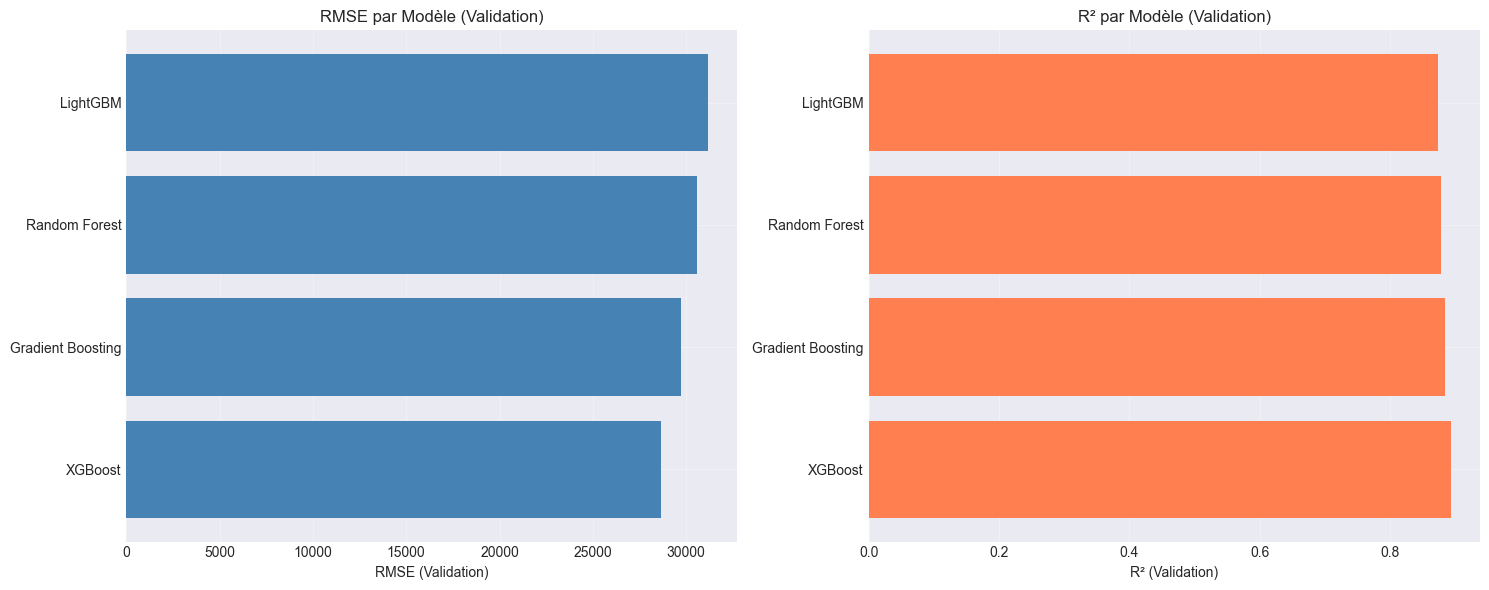

In [8]:
# Comparaison des modèles
print("=" * 60)
print("COMPARAISON DES MODÈLES")
print("=" * 60)

# Créer un DataFrame de comparaison
comparison_data = []
for model_name, result in results.items(): 
    comparison_data.append({
'Modèle': model_name,
'Train RMSE': result['train_metrics']['RMSE'],
'Val RMSE': result['val_metrics']['RMSE'],
'Train R²': result['train_metrics']['R2'],
'Val R²': result['val_metrics']['R2'],
'Val RMSE %': result['val_metrics']['RMSE_%']
})

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Val RMSE')

print("\n" + comparison_df.to_string(index=False))

# Identifier le meilleur modèle
best_model_name = comparison_df.iloc[0]['Modèle']
best_model = results[best_model_name]['model']
best_val_rmse = comparison_df.iloc[0]['Val RMSE']
best_val_r2 = comparison_df.iloc[0]['Val R²']

print(f"\n{'='*60}")
print(f"MEILLEUR MODÈLE: {best_model_name}")
print(f"{'='*60}")
print(f"   Validation RMSE: ${best_val_rmse:,.2f}")
print(f"   Validation R²: {best_val_r2:.4f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# RMSE
axes[0].barh(comparison_df['Modèle'], comparison_df['Val RMSE'], color='steelblue')
axes[0].set_xlabel('RMSE (Validation)')
axes[0].set_title('RMSE par Modèle (Validation)')
axes[0].grid(True, alpha=0.3)

# R²
axes[1].barh(comparison_df['Modèle'], comparison_df['Val R²'], color='coral')
axes[1].set_xlabel('R² (Validation)')
axes[1].set_title('R² par Modèle (Validation)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/model_comparison_modele.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Analyse des Features Importantes (Meilleur Modèle)

IMPORTANCE DES FEATURES - XGBoost

Importance des 9 features:
     Feature  Importance
 OverallQual    0.518879
  GarageCars    0.104664
 KitchenQual    0.094305
   ExterQual    0.087981
    BsmtQual    0.057013
   GrLivArea    0.056692
 TotalBsmtSF    0.040924
GarageFinish    0.026858
Neighborhood    0.012683


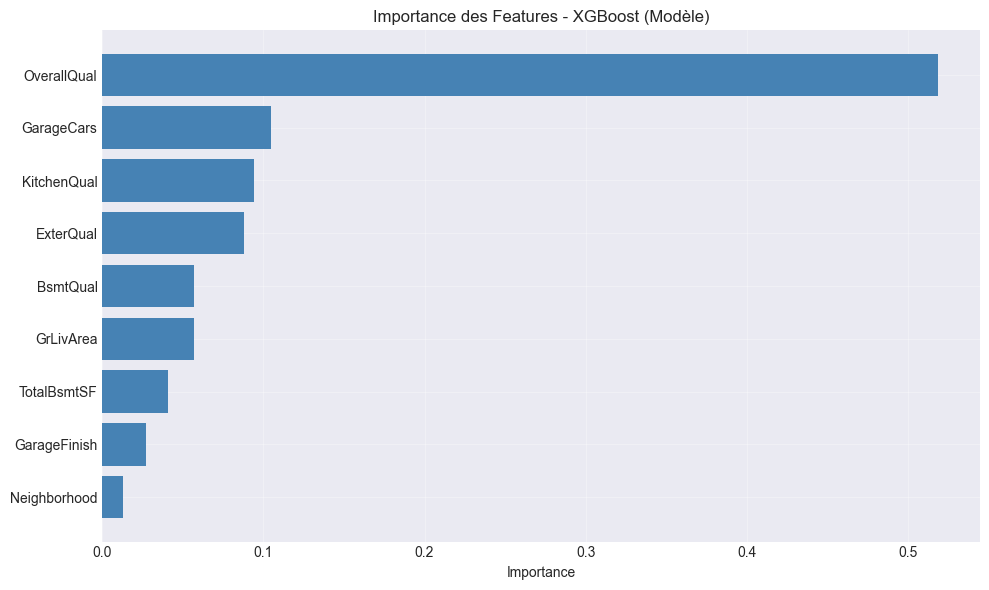

In [9]:
# Analyser l'importance des features
print("=" * 60)
print(f"IMPORTANCE DES FEATURES - {best_model_name}")
print("=" * 60)

if hasattr(best_model, 'feature_importances_'):
    # Tout ce bloc est maintenant correctement indenté sous le 'if'
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nImportance des {len(feature_importance)} features:")
    print(feature_importance.to_string(index=False))
    
    # Visualisation
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(feature_importance)), feature_importance['Importance'], color='steelblue')
    ax.set_yticks(range(len(feature_importance)))
    ax.set_yticklabels(feature_importance['Feature'])
    ax.set_xlabel('Importance')
    ax.set_title(f'Importance des Features - {best_model_name} (Modèle)')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # Pensez à vérifier que le dossier ../output/figures/ existe bien
    plt.savefig('../output/figures/feature_importance_modele.png', dpi=300, bbox_inches='tight')
    plt.show() 
else:
    # Le 'else' est maintenant aligné sur le 'if'
    print(f"\nLe modèle {best_model_name} n'a pas d'attribut feature_importances_")


## 9. Entraînement Final sur Toutes les Données

In [10]:
# Entraîner le meilleur modèle sur toutes les données d'entraînement
print("=" * 60)
print(f"ENTRAÎNEMENT FINAL SUR TOUTES LES DONNÉES - {best_model_name}")
print("=" * 60)

# Réinitialiser le modèle avec les mêmes paramètres
if best_model_name == 'LightGBM':
    final_model = LGBMRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.01,
        num_leaves=31,
        feature_fraction=0.9,
        bagging_fraction=0.9,
        bagging_freq=5,
        min_child_samples=20,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
elif best_model_name == 'XGBoost':
    final_model = XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.01,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=3,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
elif best_model_name == 'Random Forest':
    final_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
else:  # Gradient Boosting
    final_model = GradientBoostingRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.01,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )

# Entraîner sur toutes les données
final_model.fit(X_train_full, y_train_full)

# Prédictions sur l'ensemble d'entraînement
train_pred_full = final_model.predict(X_train_full)
train_metrics_full = calculate_metrics(y_train_full, train_pred_full, "Final Model - Full Train")

print(f"\nModèle final entraîné sur {X_train_full.shape[0]} observations")


ENTRAÎNEMENT FINAL SUR TOUTES LES DONNÉES - XGBoost

Final Model - Full Train:
   RMSE: $19,668.79 (10.85%)
   MAE: $13,643.86
   R²: 0.9396

Modèle final entraîné sur 1460 observations


## 10. Prédictions sur le Test Set

In [11]:
# Prédictions sur le test set
print("=" * 60)
print("PRÉDICTIONS SUR LE TEST SET")
print("=" * 60)

test_pred_log = final_model.predict(X_test_full)
test_pred = np.expm1(test_pred_log)  # Convertir en dollars

print(f"\nPrédictions générées: {len(test_pred)} observations")
print(f"Plage des prédictions: [${test_pred.min():,.0f}, ${test_pred.max():,.0f}]")
print(f"Moyenne: ${test_pred.mean():,.0f}")
print(f"Médiane: ${np.median(test_pred):,.0f}")

# Créer le DataFrame de soumission
if test_ids is not None:
    submission_df = pd.DataFrame({
        'Id': test_ids,
        'SalePrice': test_pred
    })
else:
    submission_df = pd.DataFrame({
        'Id': range(1461, 1461 + len(test_pred)),
        'SalePrice': test_pred
    })

print(f"\nDataFrame de soumission créé: {submission_df.shape}")


PRÉDICTIONS SUR LE TEST SET

Prédictions générées: 1459 observations
Plage des prédictions: [$44,981, $565,899]
Moyenne: $177,091
Médiane: $156,379

DataFrame de soumission créé: (1459, 2)


## 11. Sauvegarde des Modèles et Résultats

In [12]:
# Sauvegarder le modèle et les résultats
print("=" * 60)
print("SAUVEGARDE DES MODÈLES ET RÉSULTATS")
print("=" * 60)

# Créer le dossier de sortie
output_dir = Path("../output/models_modele")
output_dir.mkdir(parents=True, exist_ok=True)

# Sauvegarder le modèle final
model_path = output_dir / "model_modele.pkl"
joblib.dump(final_model, model_path)
print(f"\nModèle sauvegardé: {model_path}")

# Sauvegarder les label encoders (si nécessaire)
# encoder_path = output_dir / "label_encoders.pkl"
# joblib.dump(label_encoders, encoder_path)
# print(f"Label encoders sauvegardés: {encoder_path}")

# Sauvegarder la soumission
submission_path = output_dir / "submission_modele.csv"
submission_df.to_csv(submission_path, index=False)
print(f"Soumission sauvegardée: {submission_path}")

# Sauvegarder la comparaison des modèles
comparison_path = output_dir / "model_comparison_modele.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"Comparaison des modèles sauvegardée: {comparison_path}")

# Sauvegarder les métriques du modèle final
metrics_path = output_dir / "final_metrics_modele.txt"
with open(metrics_path, 'w', encoding='utf-8') as f:
    f.write(f"Modèle - 9 Variables de \n")
    f.write(f"{'='*60}\n\n")
    f.write(f"Meilleur modèle: {best_model_name}\n\n")
    f.write(f"Variables utilisées ({len(selected_features)}):\n")
    f.write(f"  {', '.join(selected_features)}\n\n")
    f.write(f"Métriques sur l'ensemble d'entraînement complet:\n")
    f.write(f"  RMSE: ${train_metrics_full['RMSE']:,.2f}\n")
    f.write(f"  MAE: ${train_metrics_full['MAE']:,.2f}\n")
    f.write(f"  R²: {train_metrics_full['R2']:.4f}\n")
    f.write(f"  RMSE (%): {train_metrics_full['RMSE_%']:.2f}%\n")

print(f"Métriques sauvegardées: {metrics_path}")

print(f"\n{'='*60}")
print("SAUVEGARDE TERMINÉE")
print(f"{'='*60}")

SAUVEGARDE DES MODÈLES ET RÉSULTATS

Modèle sauvegardé: ..\output\models_modele\model_modele.pkl
Soumission sauvegardée: ..\output\models_modele\submission_modele.csv
Comparaison des modèles sauvegardée: ..\output\models_modele\model_comparison_modele.csv
Métriques sauvegardées: ..\output\models_modele\final_metrics_modele.txt

SAUVEGARDE TERMINÉE


## 12. Résumé Final

In [13]:
# Résumé final
print("=" * 60)
print("RÉSUMÉ FINAL - MODÈLE")
print("=" * 60)

print(f"\nVariables utilisées: {len(selected_features)}")
print(f"  {', '.join(selected_features)}")
print(f"\nMeilleur modèle: {best_model_name}")
print(f"Performance sur validation:")
print(f"  - RMSE: ${best_val_rmse:,.2f}")
print(f"  - R²: {best_val_r2:.4f}")

print(f"\nPerformance sur ensemble d'entraînement complet:")
print(f"  - RMSE: ${train_metrics_full['RMSE']:,.2f}")
print(f"  - MAE: ${train_metrics_full['MAE']:,.2f}")
print(f"  - R²: {train_metrics_full['R2']:.4f}")
print(f"  - RMSE (%): {train_metrics_full['RMSE_%']:.2f}%")

print(f"\n{'='*60}")
print("MODÈLE IMPLÉMENTÉ AVEC SUCCÈS")
print(f"{'='*60}")
print(f"\nAvantages du modèle:")
print(f"  ✓ Modèle simple et interprétable ({len(selected_features)} variables)")
print(f"  ✓ Entraînement rapide")
print(f"  ✓ Moins de risque de sur-apprentissage")
print(f"  ✓ Meilleure compréhension des variables clés")
print(f"\nFichiers générés:")
print(f"  - Modèle: output/models_modele/model_modele.pkl")
print(f"  - Soumission: output/models_modele/submission_modele.csv")
print(f"  - Métriques: output/models_modele/final_metrics_modele.txt")

RÉSUMÉ FINAL - MODÈLE

Variables utilisées: 9
  OverallQual, GrLivArea, TotalBsmtSF, GarageCars, Neighborhood, ExterQual, BsmtQual, KitchenQual, GarageFinish

Meilleur modèle: XGBoost
Performance sur validation:
  - RMSE: $28,629.31
  - R²: 0.8931

Performance sur ensemble d'entraînement complet:
  - RMSE: $19,668.79
  - MAE: $13,643.86
  - R²: 0.9396
  - RMSE (%): 10.85%

MODÈLE IMPLÉMENTÉ AVEC SUCCÈS

Avantages du modèle:
  ✓ Modèle simple et interprétable (9 variables)
  ✓ Entraînement rapide
  ✓ Moins de risque de sur-apprentissage
  ✓ Meilleure compréhension des variables clés

Fichiers générés:
  - Modèle: output/models_modele/model_modele.pkl
  - Soumission: output/models_modele/submission_modele.csv
  - Métriques: output/models_modele/final_metrics_modele.txt
